# imports

In [1]:
from pathlib import Path

from jaxtyping import Float
import numpy as np
import polars as pl
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import null_stats, filter_data, normalize_data
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
)
from attention_motifs.bins import Bins
from attention_motifs.features.features import scalar_feature_table, compute_scalar_features
from attention_motifs.features.hist_beta_fit import hist_beta_fit
from attention_motifs.util import prefix_dict
from attention_motifs.features.transition_tensor import tt_features
from attention_motifs.features.vec_features import vec_features
from attention_motifs.math.cos_sim import cosine_similarity_matrix
from attention_motifs.math.math import skew_lt


# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

In [2]:
# uncomment and run to load raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")

# basic data inspection

In [3]:
DATA_RAW

feat.diag.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.col.beta_hist.hist.raw.variance,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.first_tok.rms,feat.markov_transition.diff.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.markov_transition.diff.linreg.slope,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.kurtosis,feat.first_tok.energy,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.energy,feat.markov_transition.env.upper.intercept,feat.log.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.diff.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.markov_transition.env.upper.r2,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.first_tok.kurtosis,feat.markov_transition.time.L2_norm,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.time.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.kurtosis,…,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.rms,activation.layer,feat.gram.skew.beta_hist.hist.raw.variance,feat.first_tok.autocorr_lag1,feat.diag.L2_norm,feat.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.row.beta_hist.hist.raw.median,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.std,activation.cache_key,feat.first_tok.zero_crossing_rate,feat.diag.std,feat.diag.mean,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.rms,feat.markov_transition.time.linreg.r2,feat.markov_transition.time.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.diff.entropy,feat.markov_transition.env.lower.r2,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.gram.col.beta_hist.hist.raw.median,feat.first_tok.linreg.intercept,feat.diag.linreg.intercept,feat.first_tok.psd_total_power,feat.markov_transition.time.skewness,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.596638,0.931865,-5.56048,0.200622,0.529036,0.158451,39.319073,0.0,0.185231,0.0,35.058429,0.742355,0.169934,0.0,562.813909,-0.292124,0.029276,-0.000466,0.94515,-0.055552,20.142488,108.008929,3.911398,0.979052,0.0,0.0,0.0,0.644974,0.00885,0.0,1.0,0.859375,12.67031,0.0,0.163203,0.0,23.333774,…,23.723699,94.085666,0,11563.263566,0.782999,0.022139,0.0,55.760361,8.855091,-0.290582,3.396553,111.494417,3.058511,"""blocks.0.attn.hook_pattern""",0.0,0.165037,0.169934,40381.852535,0.734656,0.0,0.0,25.775427,0.073066,1.0,0.39979,131.525631,18.311236,0.144661,1.896931,0.235895,0.261002,0.733353,null,0.0,4.927002,0.133724,0.557072
7.588164,1.08779,-5.782257,0.200622,0.666917,-0.096441,34.286382,0.0,0.158078,0.0,34.15348,0.699571,0.251202,0.0,5276.908969,-0.287297,0.0

In [4]:
set(DATA_RAW.dtypes)

{Float64, Int64, String}

In [5]:
DATA_RAW.head()

feat.diag.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.col.beta_hist.hist.raw.variance,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.first_tok.rms,feat.markov_transition.diff.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.markov_transition.diff.linreg.slope,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.kurtosis,feat.first_tok.energy,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.energy,feat.markov_transition.env.upper.intercept,feat.log.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.diff.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.markov_transition.env.upper.r2,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.first_tok.kurtosis,feat.markov_transition.time.L2_norm,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.time.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.kurtosis,…,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.rms,activation.layer,feat.gram.skew.beta_hist.hist.raw.variance,feat.first_tok.autocorr_lag1,feat.diag.L2_norm,feat.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.row.beta_hist.hist.raw.median,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.std,activation.cache_key,feat.first_tok.zero_crossing_rate,feat.diag.std,feat.diag.mean,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.rms,feat.markov_transition.time.linreg.r2,feat.markov_transition.time.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.diff.entropy,feat.markov_transition.env.lower.r2,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.gram.col.beta_hist.hist.raw.median,feat.first_tok.linreg.intercept,feat.diag.linreg.intercept,feat.first_tok.psd_total_power,feat.markov_transition.time.skewness,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.596638,0.931865,-5.56048,0.200622,0.529036,0.158451,39.319073,0.0,0.185231,0.0,35.058429,0.742355,0.169934,0.0,562.813909,-0.292124,0.029276,-0.000466,0.94515,-0.055552,20.142488,108.008929,3.911398,0.979052,0.0,0.0,0.0,0.644974,0.00885,0.0,1.0,0.859375,12.67031,0.0,0.163203,0.0,23.333774,…,23.723699,94.085666,0,11563.263566,0.782999,0.022139,0.0,55.760361,8.855091,-0.290582,3.396553,111.494417,3.058511,"""blocks.0.attn.hook_pattern""",0.0,0.165037,0.169934,40381.852535,0.734656,0.0,0.0,25.775427,0.073066,1.0,0.39979,131.525631,18.311236,0.144661,1.896931,0.235895,0.261002,0.733353,null,0.0,4.927002,0.133724,0.557072
7.588164,1.08779,-5.782257,0.200622,0.666917,-0.096441,34.286382,0.0,0.158078,0.0,34.15348,0.699571,0.251202,0.0,5276.908969,-0.287297,0.0

In [6]:
DATA_RAW.describe()

statistic,feat.diag.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.col.beta_hist.hist.raw.variance,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.first_tok.rms,feat.markov_transition.diff.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.markov_transition.diff.linreg.slope,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.kurtosis,feat.first_tok.energy,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.energy,feat.markov_transition.env.upper.intercept,feat.log.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.diff.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.markov_transition.env.upper.r2,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.first_tok.kurtosis,feat.markov_transition.time.L2_norm,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.time.autocorr_lag1,…,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.rms,activation.layer,feat.gram.skew.beta_hist.hist.raw.variance,feat.first_tok.autocorr_lag1,feat.diag.L2_norm,feat.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.row.beta_hist.hist.raw.median,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.std,activation.cache_key,feat.first_tok.zero_crossing_rate,feat.diag.std,feat.diag.mean,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.rms,feat.markov_transition.time.linreg.r2,feat.markov_transition.time.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.diff.entropy,feat.markov_transition.env.lower.r2,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.gram.col.beta_hist.hist.raw.median,feat.first_tok.linreg.intercept,feat.diag.linreg.intercept,feat.first_tok.psd_total_power,feat.markov_transition.time.skewness,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.L2_norm
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,…,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,"""123872""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,829.0,123872.0,123872.0,123872.0,123872.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [7]:
# print unique values for columns which start with "activations"
print(f"{DATA_RAW['activation.model'].unique() = }")

DATA_RAW['activation.model'].unique() = shape: (6,)
Series: 'activation.model' [str]
[
	"gpt2-medium"
	"tiny-stories-1M"
	"gpt2-small"
	"pythia-14m"
	"pythia-1b"
	"gemma-2b"
]


In [8]:
for col in DATA_RAW.columns:
	if col.startswith("activation"):
		print(f"{col = }")

col = 'activation.model'
col = 'activation.n_ctx'
col = 'activation.head'
col = 'activation.cls'
col = 'activation.prompt'
col = 'activation.layer'
col = 'activation.cache_key'


In [9]:
null_stats(DATA_RAW)

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.time.ku…",123043,0.993308
"""feat.markov_transition.time.sk…",123043,0.993308
"""feat.diag.psd_total_power""",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.skew.beta_hist.hist.…",0,0.0
…,…,…
"""feat.first_tok.psd_total_power""",0,0.0
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0


# filter nans and certain models

In [10]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 feat.* columns due to zero variance or excessive missing values
feat.gram.col.beta_hist.hist.raw.zero_crossing_rate          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.diff.autocorr_lag1                    μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate     μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.energy                           μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.env.upper.intercept                   μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.row.beta_hist.hist.raw.median                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate      μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] 

feature,missing_count,missing_frac
str,i64,f64
"""feat.diag.psd_total_power""",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
…,…,…
"""feat.diag.linreg.intercept""",0,0.0
"""feat.first_tok.psd_total_power""",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0


# scaling

In [11]:
# Pick feature columns
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]

In [ ]:
DATA_SCALED: pl.DataFrame
DATA_NORMS: pl.DataFrame
DATA_SCALED, DATA_NORMS = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_NORMS.write_ndjson(PATH_BASE / "scaling.jsonl")
DATA_SCALED

feat.diag.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.col.beta_hist.hist.raw.variance,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.first_tok.rms,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.L1_norm,feat.gram.row.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.markov_transition.diff.linreg.slope,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.kurtosis,feat.first_tok.energy,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.diff.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.first_tok.kurtosis,feat.log.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.std,feat.markov_transition.diff.mean,feat.log.gram.skew.beta_hist.hist.raw.median,feat.log.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.energy,activation.model,feat.gram.col.beta_hist.hist.raw.std,feat.first_tok.entropy,feat.log.gram.row.beta_hist.hist.raw.std,…,feat.diag.median,feat.first_tok.skewness,feat.markov_transition.diff.std,feat.markov_transition.diff.L1_norm,activation.prompt,feat.first_tok.std,feat.markov_transition.diff.linreg.r2,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.rms,activation.layer,feat.gram.skew.beta_hist.hist.raw.variance,feat.first_tok.autocorr_lag1,feat.diag.L2_norm,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.row.beta_hist.hist.raw.median,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.std,activation.cache_key,feat.diag.std,feat.diag.mean,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.diff.entropy,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.gram.col.beta_hist.hist.raw.median,feat.first_tok.linreg.intercept,feat.diag.linreg.intercept,feat.first_tok.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,…,f64,f64,f64,f64,str,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.450932,-0.008704,0.060201,-0.339936,0.988711,-0.451801,-0.688287,0.274522,-0.692114,-0.663572,0.204746,-0.222328,0.814896,-0.724653,0.305812,-0.485985,0.210352,-0.288697,-0.057261,0.075595,-0.554036,-1.127713,-0.266285,-0.687398,-0.375439,-0.7244,0.473904,0.967734,-0.266285,1.532475,0.339087,-0.266664,0.964072,"""gemma-2b""",0.878836,0.604305,0.836533,…,-0.002193,-0.631021,-0.21145,-0.266285,"""MjWkadUxH4Z5nfLEFtUc1w""",0.833364,-0.264634,-0.340838,0.870882,0,0.987323,-1.946191,0.28935,-0.283626,0.55133,0.724929,0.76821,0.992118,-0.277801,"""blocks.0.attn.hook_pattern""",1.713928,0.204746,-0.465602,0.970525,0.346838,-0.245457,-0.682661,-0.337689,0.862457,-0.863237,-0.552569,0.155735,0.045931,0.489934,0.493229,0.839435,-0.266664
-0.290415,-0.152863,0.178019,-0.339936,1.070952,-0.361498,-1.239186,0.282435,-1.049617,-1.046432,-0.382406,-0.193524,0.971801,-0.724653,0.305812,-0.36259,0.251842,0.343294,-0.057261,0.08324,0.544505,-1.4

In [13]:
null_stats(DATA_SCALED)

feature,missing_count,missing_frac
str,i64,f64
"""feat.diag.psd_total_power""",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
…,…,…
"""feat.diag.linreg.intercept""",0,0.0
"""feat.first_tok.psd_total_power""",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0


In [ ]:
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")

# PCA

In [14]:
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())

[ <ipykernel>:1 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=-0.00 σ=1.00 x̃=-0.16 R=[-16.09,25.89] ℙ=|▁▄█▆▃▂▁| shape=(104416,139) dtype=float64


array([[ 1.45093167, -0.00870369,  0.06020083, ...,  0.49322902,
         0.83943494, -0.26666411],
       [-0.29041467, -0.15286339,  0.17801927, ...,  0.49322902,
         0.83943494, -0.26873744],
       [ 0.06946384, -0.40660549, -0.9872337 , ...,  0.49322502,
         0.83433024, -0.27172774],
       ...,
       [-0.10709562,  0.42322554,  0.21441747, ...,  0.21460272,
        -0.35469683,  0.38235289],
       [-0.35394728,  0.14822708,  0.53591334, ...,  0.34300884,
        -0.06521912,  0.37865922],
       [-0.2840185 ,  0.1463996 ,  1.04768644, ..., -0.52996067,
        -1.22373552,  0.38155397]])

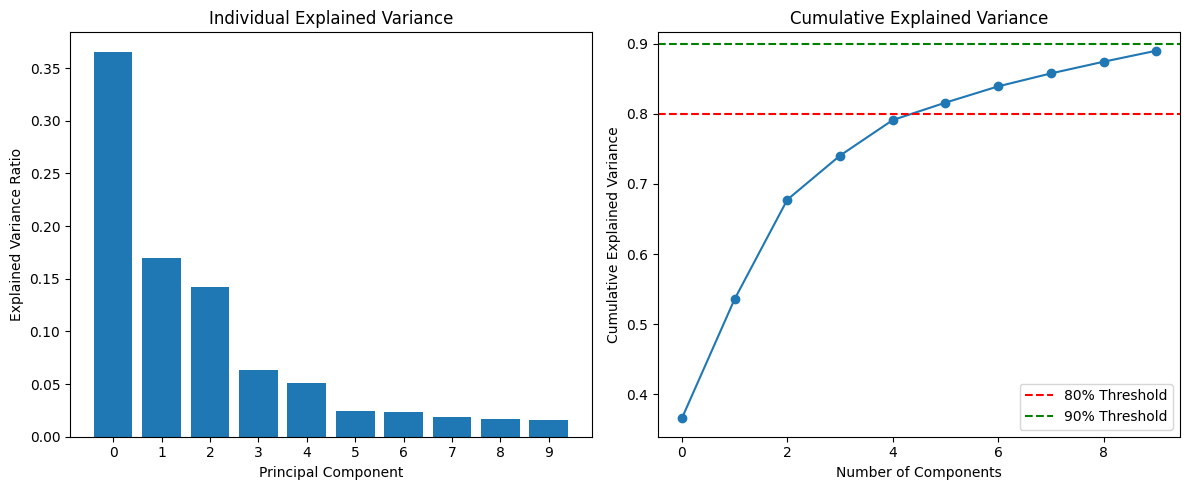

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


In [15]:
# PCA
pca_data: np.ndarray
pca_obj: PCA
pca_data, pca_obj = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)

In [ ]:
# save some data
dbg_tensor(pca_data)
np.save(PATH_BASE / "pca.npy", pca_data)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[
	[col for col in DATA_SCALED.columns if col.startswith("activation.")]
]
data_meta = data_meta.write_ndjson(PATH_BASE / "meta.jsonl")

[ <ipykernel>:3 ] pca_data: μ=0.00 σ=3.52 x̃=-0.07 R=[-35.88,27.20] ℙ=|▃▄▅█▇▅▄| shape=(104416,10) dtype=float64


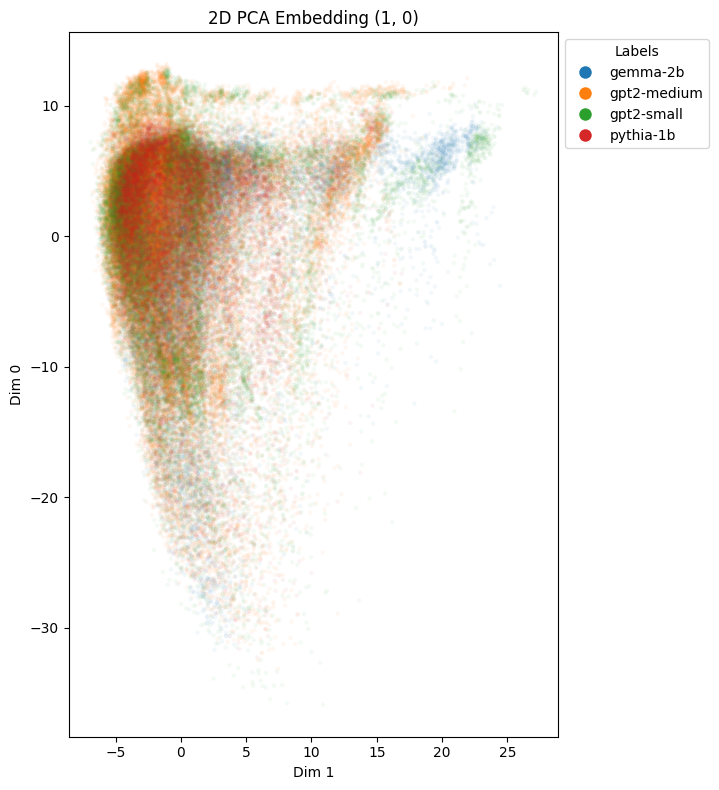

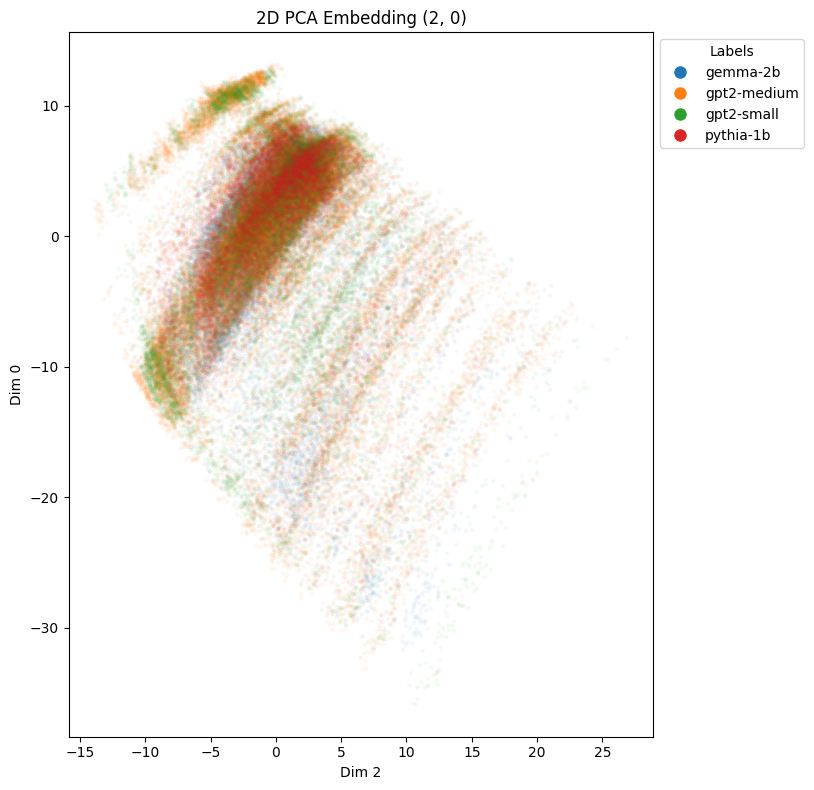

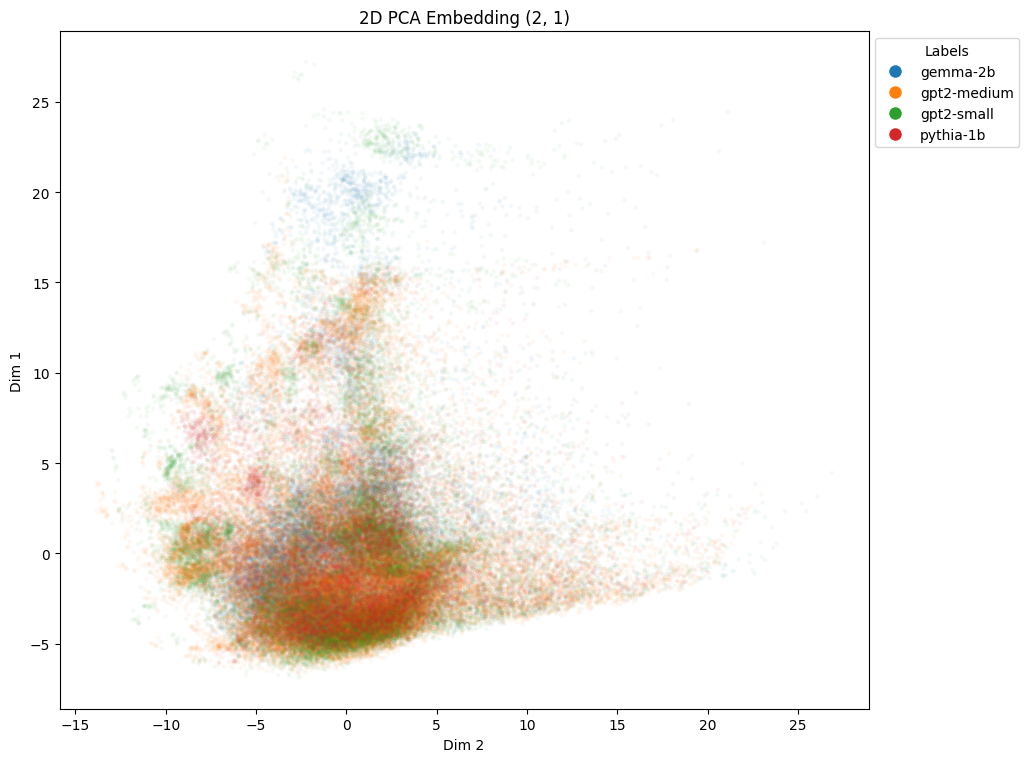

In [17]:
for i in range(1, 3):
	for j in range(0, i):
		plot_embedding(
			pca_data,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=10,
			title=f"2D PCA Embedding ({i}, {j})",
		)